In [4]:
from warnings import filterwarnings
filterwarnings('ignore')

In [5]:
import tensorflow as tf # type: ignore
print(tf.__version__)

2.20.0


In [ ]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D # type: ignore

In [7]:
data = pd.read_csv('image_data_training.csv')
data.head()

,id,0,1,2,3,4,5,6,7,8,...,776,777,778,779,780,781,782,783,784,class
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
x = data.drop(['class', 'id', '0'], axis=1)
y = data['class']
print(x.shape, y.shape)

(60010, 784) (60010,)


In [10]:
x = x.values.reshape(-1, 28, 28, 1) 


In [3]:
# Load the MNIST dataset and normalize the pixel values
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
# reshape the data for the CNN model
x_train = x_train.reshape(-1, 28, 28, 1)  # 28x28 images with 1 channel (grayscale)
x_test = x_test.reshape(-1, 28, 28, 1)

In [11]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

In [12]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
summary = model.fit(x, y, epochs=5, verbose=1)

Epoch 1/5
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.9514 - loss: 0.3644
Epoch 2/5
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9822 - loss: 0.0585
Epoch 3/5
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9850 - loss: 0.0482
Epoch 4/5
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9880 - loss: 0.0392
Epoch 5/5
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9890 - loss: 0.0360


In [16]:
x_test = pd.read_csv('image_data_test.csv')
y_test = pd.read_csv('test_label.csv')
x_test = x_test.drop(['id', '0'], axis=1)
x_test = x_test.values.reshape(-1, 28, 28, 1)
y_test = y_test['class']
val_loss , val_accuracy = model.evaluate(x_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9861 - loss: 0.0508


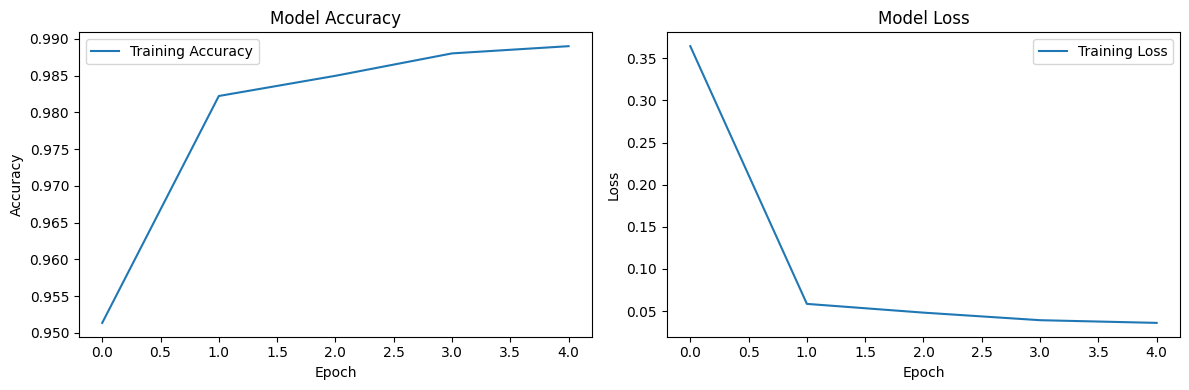

In [20]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(summary.history['accuracy'], label='Training Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(summary.history['loss'], label='Training Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
model.save('handwritten_digit_model.keras')

In [8]:
model.save('mnist_cnn_model.h5')